In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

dataset = "qqp"
seed = 2025
selected_dp_percent = [i for i in range(1, 101)]
iteration = 500


def plot_data_selection(seed, dataset, train_data, g, iteration=500):
    """Plot 9-subplot data-selection figure for one (dataset, train_data) setting.

    Looks up the following variables from g (caller's globals()):
      - seed{seed}_{dataset}_{train_data}_inv_lam1e_6
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_inv1e_6     (R in ranks)
      - seed{seed}_{dataset}_{train_data}_r{R}_eigen1e_2_eigen1e_2   (R in ranks)
      - seed{seed}_{dataset}_{train_data}_A_BASE
      - seed{seed}_{dataset}_{train_data}_inv_early_stop
      - seed{seed}_{dataset}_{train_data}_topr_early_stop
      - selected_dp_percent  (shared)
    """
    selected_dp_percent = g["selected_dp_percent"]
    inv             = g[f"seed{seed}_{dataset}_{train_data}_inv_lam1e_6"]
    A_BASE          = g[f"seed{seed}_{dataset}_{train_data}_A_BASE"]
    inv_early_stop  = g[f"seed{seed}_{dataset}_{train_data}_inv_early_stop"]
    topr_early_stop = g[f"seed{seed}_{dataset}_{train_data}_topr_early_stop"]

    ranks = [1, 5, 10, 15, 20, 25, 30]
    eigen_data_1 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_eigen1e_2"], f"rank {r}%") for r in ranks]
    eigen_data_2 = [(g[f"seed{seed}_{dataset}_{train_data}_r{r}_eigen1e_2_inv1e_6"],   f"rank {r}%") for r in ranks]
    diff_data    = [(np.array(d1) - np.array(d2), lab)
                    for (d1, lab), (d2, _) in zip(eigen_data_1, eigen_data_2)]

    num_dp = train_data
    ZOOM_PCT = 20
    ZOOM_N = ZOOM_PCT

    fig, axes = plt.subplots(3, 3, figsize=(30, 28))
    axes = axes.flatten()

    inv_color = "red"
    eigen_colors = plt.cm.viridis(np.linspace(0.1, 0.9, 7))

    # ===== Subplot (1,1): Eigen mode (shapley + prediction) - 1~ZOOM_PCT% =====
    ax1 = axes[0]
    plot_percent_10 = selected_dp_percent[:ZOOM_N]
    ax1.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax1.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)

    all_data_10_eigen = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_1]
    y_min_10 = min(min(d) for d in all_data_10_eigen)
    y_max_10 = max(max(d) for d in all_data_10_eigen)
    y_margin_10 = (y_max_10 - y_min_10) * 0.1
    ylim_10_min = y_min_10 - y_margin_10
    ylim_10_max = y_max_10 + y_margin_10

    ax1.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax1.set_ylabel("Accuracy", fontsize=20)
    ax1.set_title(f"Eigen Shapley + Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax1.legend(fontsize=20, loc="best")
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax1.set_ylim(ylim_10_min, ylim_10_max)
    ax1.tick_params(axis="both", labelsize=18)

    # ===== Subplot (1,2): Eigen shapley + INV prediction - 1~ZOOM_PCT% =====
    ax2 = axes[1]
    ax2.plot(plot_percent_10, inv[:ZOOM_N], color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=10, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax2.plot(plot_percent_10, data[:ZOOM_N], color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)

    all_data_10_inv = [inv[:ZOOM_N]] + [d[0][:ZOOM_N] for d in eigen_data_2]
    y_min_10_inv = min(min(d) for d in all_data_10_inv)
    y_max_10_inv = max(max(d) for d in all_data_10_inv)
    ylim_10_min = min(ylim_10_min, y_min_10_inv - (y_max_10_inv - y_min_10_inv) * 0.1)
    ylim_10_max = max(ylim_10_max, y_max_10_inv + (y_max_10_inv - y_min_10_inv) * 0.1)

    ax2.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax2.set_ylabel("Accuracy", fontsize=20)
    ax2.set_title(f"Eigen Shapley + INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax2.legend(fontsize=20, loc="best")
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax2.set_ylim(ylim_10_min, ylim_10_max)
    ax2.tick_params(axis="both", labelsize=18)

    ax1.set_ylim(ylim_10_min, ylim_10_max)

    # ===== Subplot (1,3): Difference (Eigen - INV) - 1~100% =====
    ax3 = axes[2]
    for i, (data, label) in enumerate(diff_data):
        ax3.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="d", markersize=6, label=label, alpha=0.85)

    all_diff_data = [d[0] for d in diff_data]
    y_min_diff = min(min(d) for d in all_diff_data)
    y_max_diff = max(max(d) for d in all_diff_data)
    y_margin_diff = max(abs(y_min_diff), abs(y_max_diff)) * 0.1
    ylim_diff_min = y_min_diff - y_margin_diff
    ylim_diff_max = y_max_diff + y_margin_diff

    ax3.axhline(y=0, color="black", linestyle="--", linewidth=1.5, alpha=0.5)
    ax3.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax3.set_ylabel("Accuracy Difference", fontsize=20)
    ax3.set_title(f"Difference (Eigen Pred - INV Pred) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax3.legend(fontsize=20, loc="best")
    ax3.grid(True, alpha=0.3)
    ax3.set_xlim(0, 101)
    ax3.set_ylim(ylim_diff_min, ylim_diff_max)
    ax3.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,1): Eigen mode (shapley + prediction) - 1~100% =====
    ax4 = axes[3]
    ax4.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_1):
        ax4.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=6, label=label, alpha=0.85)

    all_data_100_eigen = [inv] + [d[0] for d in eigen_data_1]
    y_min_100 = min(min(d) for d in all_data_100_eigen)
    y_max_100 = max(max(d) for d in all_data_100_eigen)
    y_margin_100 = (y_max_100 - y_min_100) * 0.1
    ylim_100_min = y_min_100 - y_margin_100
    ylim_100_max = y_max_100 + y_margin_100

    ax4.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax4.set_ylabel("Accuracy", fontsize=20)
    ax4.set_title(f"Eigen Shapley + Eigen Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax4.legend(fontsize=20, loc="best")
    ax4.grid(True, alpha=0.3)
    ax4.set_xlim(0, 101)
    ax4.set_ylim(ylim_100_min, ylim_100_max)
    ax4.tick_params(axis="both", labelsize=18)

    # ===== Subplot (2,2): Eigen shapley + INV prediction - 1~100% =====
    ax5 = axes[4]
    ax5.plot(selected_dp_percent, inv, color=inv_color, linewidth=2.5,
             linestyle="-", marker="o", markersize=6, label="INV λ=1e-6", alpha=0.85)
    for i, (data, label) in enumerate(eigen_data_2):
        ax5.plot(selected_dp_percent, data, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=6, label=label, alpha=0.85)

    all_data_100_inv = [inv] + [d[0] for d in eigen_data_2]
    y_min_100_inv = min(min(d) for d in all_data_100_inv)
    y_max_100_inv = max(max(d) for d in all_data_100_inv)
    ylim_100_min = min(ylim_100_min, y_min_100_inv - (y_max_100_inv - y_min_100_inv) * 0.1)
    ylim_100_max = max(ylim_100_max, y_max_100_inv + (y_max_100_inv - y_min_100_inv) * 0.1)

    ax5.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax5.set_ylabel("Accuracy", fontsize=20)
    ax5.set_title(f"Eigen Shapley + INV Pred (1-100%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax5.legend(fontsize=20, loc="best")
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim(0, 101)
    ax5.set_ylim(ylim_100_min, ylim_100_max)
    ax5.tick_params(axis="both", labelsize=18)

    ax4.set_ylim(ylim_100_min, ylim_100_max)

    # ===== Subplot (2,3): Early Stop Ratio =====
    ax6 = axes[5]
    method_names = ["INV"] + [f"rank {r}%" for r in ranks]
    method_values = [inv_early_stop[0]] + list(topr_early_stop)
    bar_colors = [inv_color] + list(eigen_colors)
    x_pos = np.arange(len(method_names))
    bars = ax6.bar(x_pos, method_values, color=bar_colors, alpha=0.85, edgecolor="black", linewidth=1.2)
    for bar, value in zip(bars, method_values):
        ax6.text(bar.get_x() + bar.get_width() / 2., bar.get_height(),
                 f"{value:.2f}", ha="center", va="bottom", fontsize=20, fontweight="bold")
    ax6.set_xlabel("Method", fontsize=20)
    ax6.set_ylabel("Early Stop Ratio (%)", fontsize=20)
    ax6.set_title(f"Early Stop Ratio (%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax6.set_xticks(x_pos)
    ax6.set_xticklabels(method_names, fontsize=20)
    ax6.grid(True, alpha=0.3, axis="y")
    ax6.tick_params(axis="y", labelsize=18)

    # ===== Subplot (3,1): ER for Eigen Pred - 1~ZOOM_PCT% =====
    ax7 = axes[6]
    inv_zoom_arr = np.array(inv[:ZOOM_N])

    er_data_eigen = []
    for i, (data, label) in enumerate(eigen_data_1):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_eigen.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_eigen):
        ax7.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="s", markersize=10, label=label, alpha=0.85)
    ax7.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax7.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax7.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax7.set_title(f"ER: Eigen Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax7.legend(fontsize=20, loc="best")
    ax7.grid(True, alpha=0.3)
    ax7.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax7.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,2): ER for INV Pred - 1~ZOOM_PCT% =====
    ax8 = axes[7]
    er_data_inv = []
    for i, (data, label) in enumerate(eigen_data_2):
        ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
        er_data_inv.append((ers, f"{label} ({np.mean(ers):.3f}±{np.std(ers):.3f})"))

    for i, (ers, label) in enumerate(er_data_inv):
        ax8.plot(plot_percent_10, ers, color=eigen_colors[i], linewidth=2.5,
                 linestyle="-", marker="^", markersize=10, label=label, alpha=0.85)
    ax8.axhline(y=1.0, color="black", linestyle="--", linewidth=1.5, alpha=0.5, label="y=1 (baseline)")
    ax8.set_xlabel("Selected Data Percentage (%)", fontsize=20)
    ax8.set_ylabel("Excess Retention (ER)", fontsize=20)
    ax8.set_title(f"ER: INV Pred (1-{ZOOM_PCT}%) | Data: {num_dp}, Iter: {iteration}", fontsize=20)
    ax8.legend(fontsize=20, loc="best")
    ax8.grid(True, alpha=0.3)
    ax8.set_xlim(0.5, ZOOM_PCT + 0.5)
    ax8.tick_params(axis="both", labelsize=18)

    # ===== Subplot (3,3): Turn off =====
    axes[8].axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:

# ===== Configuration =====
num_dp = 1000
# =========================

seed2025_qqp_1000_A_BASE = 

seed2025_qqp_1000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_qqp_1000_r1_eigen1e_2_inv1e_6  = 
seed2025_qqp_1000_r5_eigen1e_2_inv1e_6  = 
seed2025_qqp_1000_r10_eigen1e_2_inv1e_6 = 
seed2025_qqp_1000_r15_eigen1e_2_inv1e_6 = 
seed2025_qqp_1000_r20_eigen1e_2_inv1e_6 = 
seed2025_qqp_1000_r25_eigen1e_2_inv1e_6 = 
seed2025_qqp_1000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_qqp_1000_r1_eigen1e_2_eigen1e_2  = 
seed2025_qqp_1000_r5_eigen1e_2_eigen1e_2  = 
seed2025_qqp_1000_r10_eigen1e_2_eigen1e_2 = 
seed2025_qqp_1000_r15_eigen1e_2_eigen1e_2 = 
seed2025_qqp_1000_r20_eigen1e_2_eigen1e_2 = 
seed2025_qqp_1000_r25_eigen1e_2_eigen1e_2 = 
seed2025_qqp_1000_r30_eigen1e_2_eigen1e_2 = 

seed2025_qqp_1000_inv_early_stop  = []
seed2025_qqp_1000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 2000
# =========================

seed2025_qqp_2000_A_BASE = 

seed2025_qqp_2000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_qqp_2000_r1_eigen1e_2_inv1e_6  = 
seed2025_qqp_2000_r5_eigen1e_2_inv1e_6  = 
seed2025_qqp_2000_r10_eigen1e_2_inv1e_6 = 
seed2025_qqp_2000_r15_eigen1e_2_inv1e_6 = 
seed2025_qqp_2000_r20_eigen1e_2_inv1e_6 = 
seed2025_qqp_2000_r25_eigen1e_2_inv1e_6 = 
seed2025_qqp_2000_r30_eigen1e_2_inv1e_6 = 

# Prediction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_qqp_2000_r1_eigen1e_2_eigen1e_2  = 
seed2025_qqp_2000_r5_eigen1e_2_eigen1e_2  = 
seed2025_qqp_2000_r10_eigen1e_2_eigen1e_2 = 
seed2025_qqp_2000_r15_eigen1e_2_eigen1e_2 = 
seed2025_qqp_2000_r20_eigen1e_2_eigen1e_2 = 
seed2025_qqp_2000_r25_eigen1e_2_eigen1e_2 = 
seed2025_qqp_2000_r30_eigen1e_2_eigen1e_2 = 

seed2025_qqp_2000_inv_early_stop  = []
seed2025_qqp_2000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


/tmp/ipykernel_1028525/667573839.py:191: RuntimeWarning: divide by zero encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/tmp/ipykernel_1028525/667573839.py:191: RuntimeWarning: invalid value encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/home/donghwan/.conda/envs/freeshap/lib/python3.10/site-packages/numpy/core/_methods.py:233: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/tmp/ipykernel_1028525/667573839.py:210: RuntimeWarning: divide by zero encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)
/tmp/ipykernel_1028525/667573839.py:210: RuntimeWarning: invalid value encountered in divide
  ers = (np.array(data[:ZOOM_N]) - A_BASE) / (inv_zoom_arr - A_BASE)


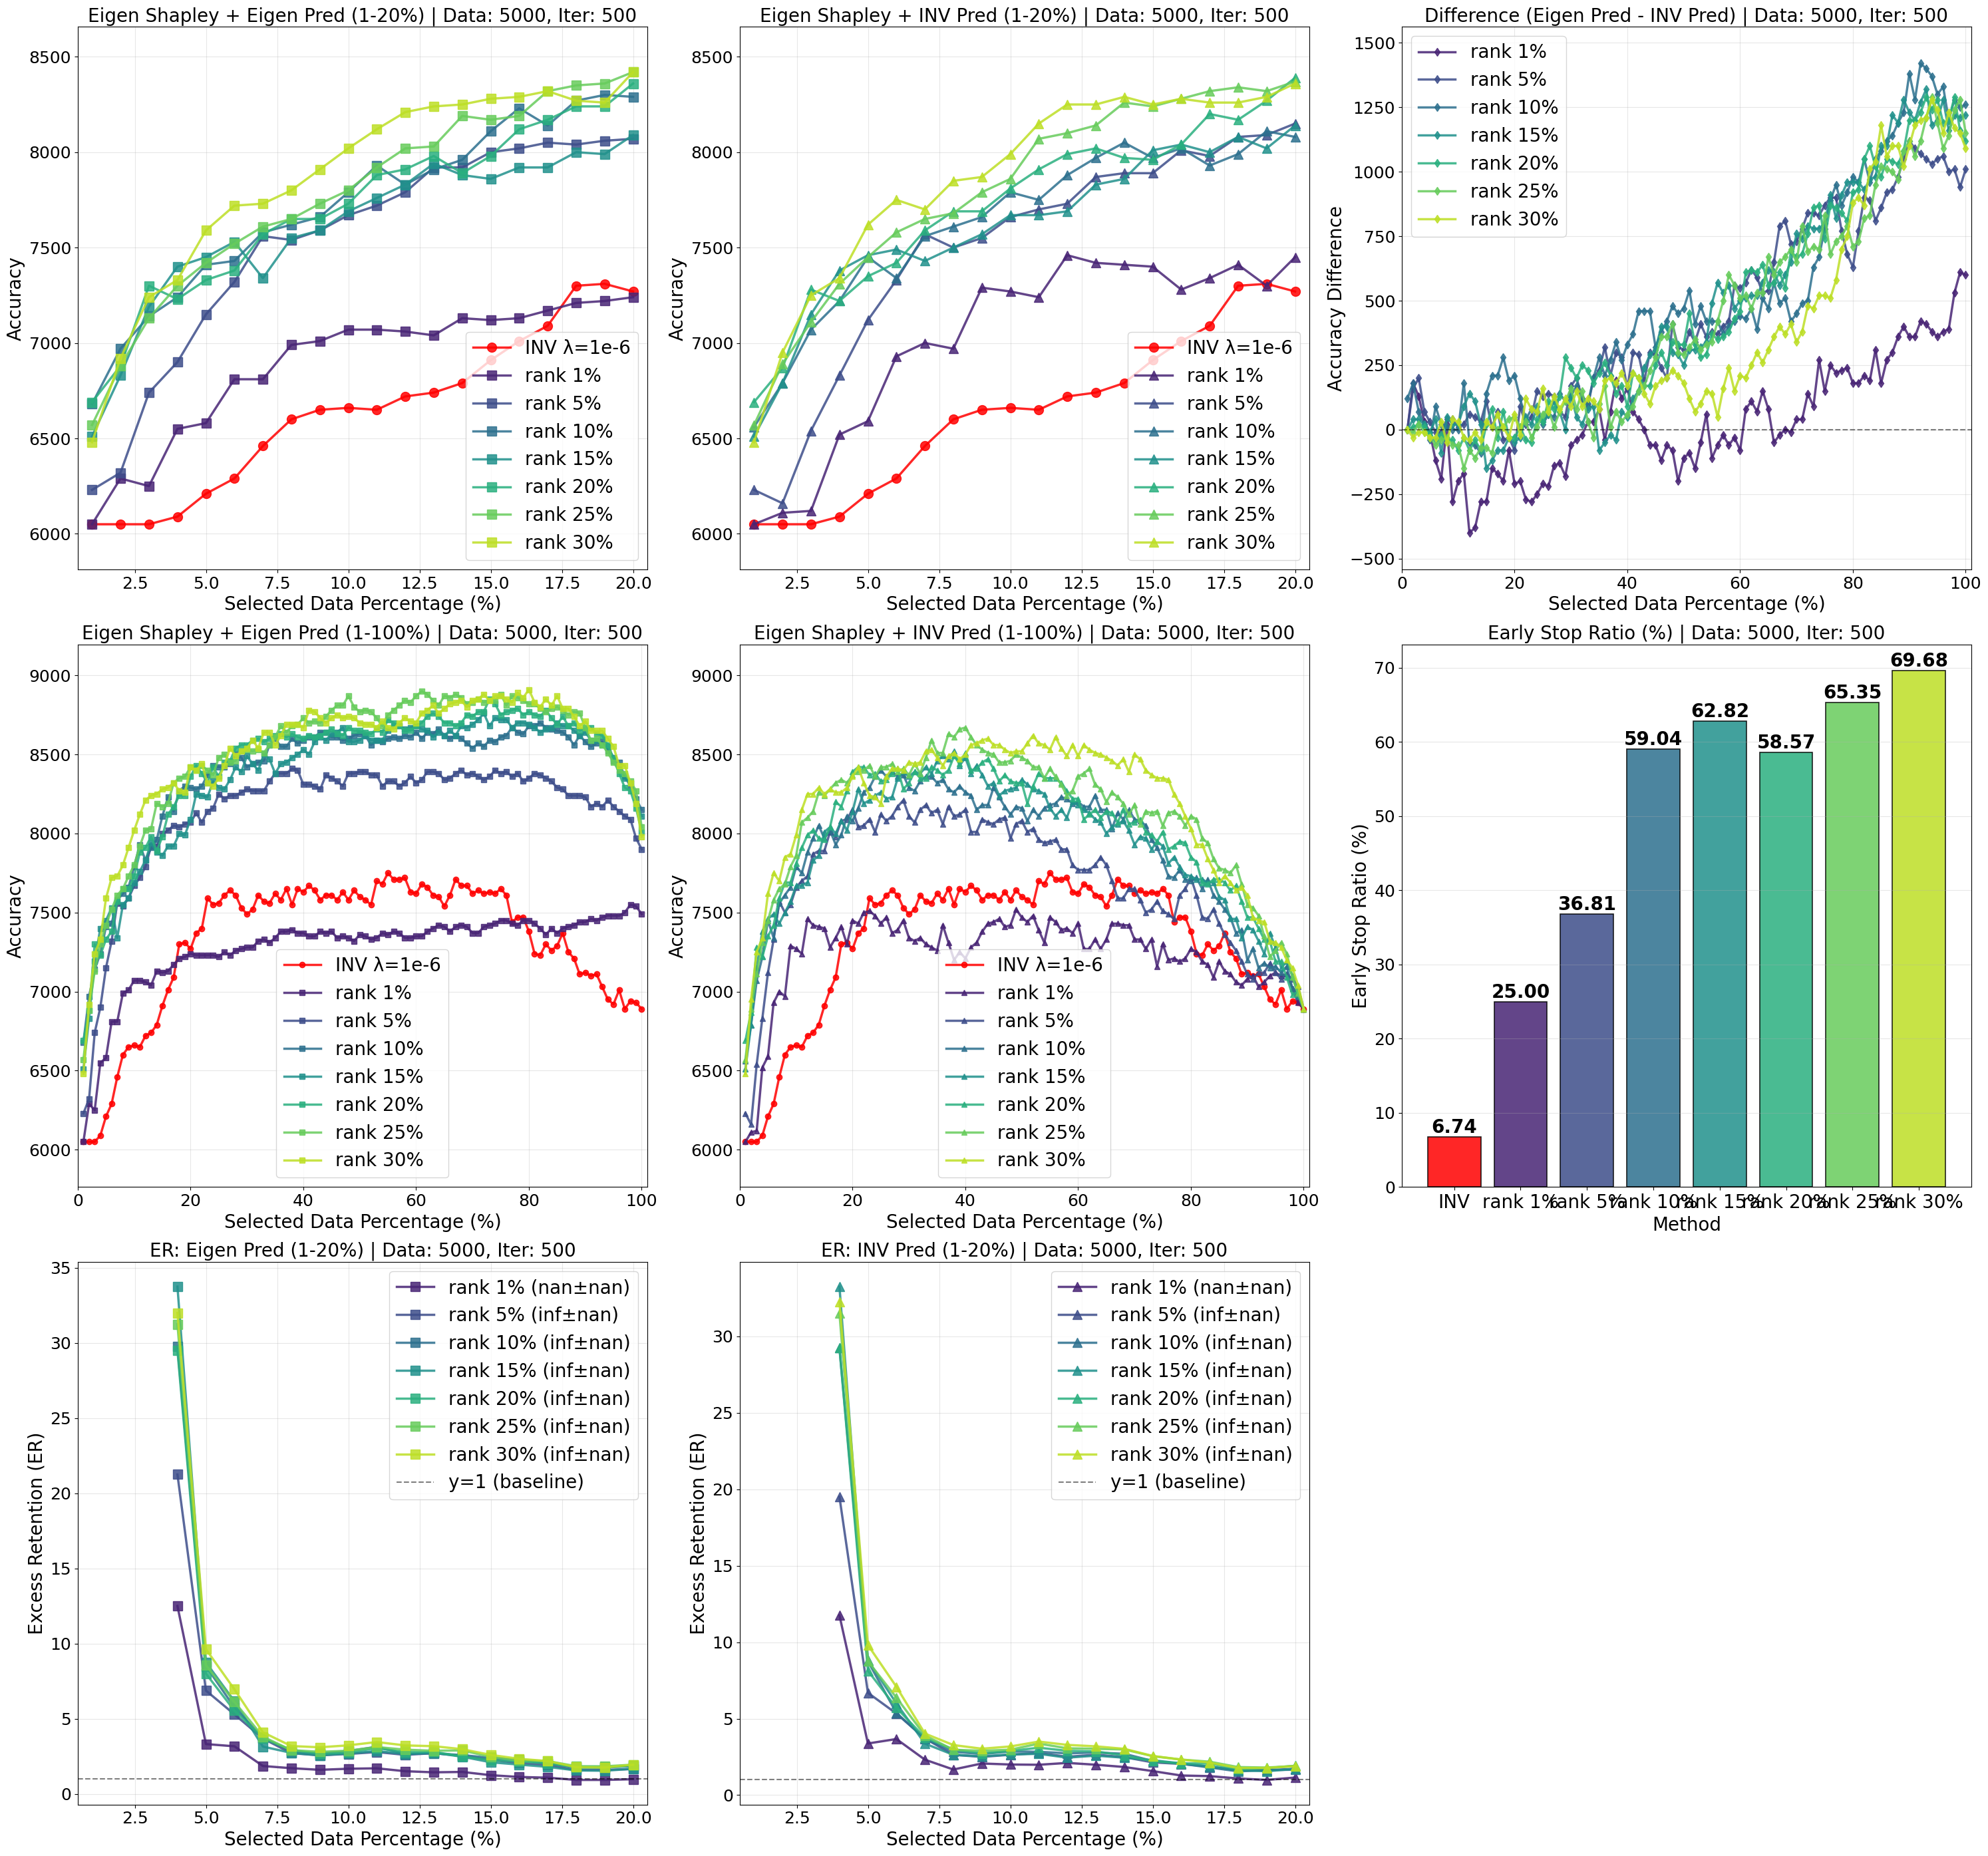

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 5000
# =========================

seed2025_qqp_5000_A_BASE = 6050

seed2025_qqp_5000_inv_lam1e_6           = [6050, 6050, 6050, 6090, 6210, 6290, 6460, 6600, 6650, 6660, 6650, 6720, 6740, 6790, 6910, 7010, 7090, 7300, 7310, 7270, 7370, 7400, 7590, 7550, 7560, 7610, 7640, 7610, 7530, 7490, 7520, 7610, 7570, 7560, 7620, 7580, 7650, 7550, 7650, 7630, 7670, 7640, 7580, 7610, 7610, 7580, 7630, 7580, 7640, 7600, 7580, 7550, 7700, 7680, 7750, 7710, 7710, 7720, 7630, 7620, 7680, 7660, 7610, 7600, 7540, 7610, 7710, 7670, 7670, 7620, 7640, 7620, 7630, 7620, 7650, 7610, 7440, 7470, 7470, 7380, 7240, 7230, 7300, 7260, 7290, 7370, 7250, 7210, 7110, 7120, 7100, 7110, 7030, 6950, 6920, 7010, 6890, 6940, 6930, 6890]
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_qqp_5000_r1_eigen1e_2_inv1e_6  = [6050, 6110, 6120, 6520, 6590, 6930, 7000, 6970, 7290, 7270, 7240, 7460, 7420, 7410, 7400, 7280, 7340, 7410, 7300, 7450, 7430, 7500, 7510, 7480, 7430, 7470, 7370, 7390, 7450, 7340, 7320, 7340, 7300, 7280, 7260, 7420, 7310, 7200, 7250, 7210, 7280, 7310, 7380, 7430, 7440, 7460, 7410, 7420, 7520, 7470, 7440, 7480, 7390, 7310, 7470, 7440, 7390, 7400, 7370, 7430, 7270, 7270, 7330, 7270, 7330, 7430, 7430, 7420, 7420, 7330, 7330, 7270, 7330, 7160, 7300, 7200, 7210, 7190, 7210, 7270, 7250, 7190, 7170, 7090, 7190, 7130, 7110, 7060, 7040, 7080, 7100, 7030, 7060, 7100, 7120, 7100, 7110, 7020, 6930, 6890]
seed2025_qqp_5000_r5_eigen1e_2_inv1e_6  = [6230, 6160, 6540, 6830, 7120, 7330, 7570, 7500, 7550, 7660, 7700, 7730, 7870, 7890, 7890, 8010, 7980, 8080, 8090, 8150, 8040, 8050, 8090, 8010, 8120, 8080, 8110, 8170, 8210, 8110, 8070, 8150, 8180, 8130, 8150, 8060, 8170, 8110, 8120, 8150, 8010, 8010, 8090, 8070, 8060, 8090, 8100, 7970, 8060, 8080, 8010, 8030, 7960, 7940, 7950, 7960, 7900, 7900, 7800, 7770, 7770, 7770, 7800, 7850, 7800, 7700, 7590, 7590, 7650, 7650, 7580, 7500, 7520, 7570, 7510, 7490, 7460, 7610, 7650, 7720, 7610, 7470, 7460, 7520, 7430, 7360, 7310, 7260, 7190, 7110, 7080, 7120, 7120, 7180, 7120, 7080, 7110, 7080, 7030, 6890]
seed2025_qqp_5000_r10_eigen1e_2_inv1e_6 = [6560, 6790, 7070, 7220, 7450, 7340, 7560, 7610, 7660, 7790, 7750, 7880, 7970, 8050, 7970, 8020, 7930, 7990, 8110, 8080, 8160, 8260, 8290, 8360, 8400, 8360, 8390, 8360, 8370, 8290, 8270, 8330, 8360, 8360, 8320, 8340, 8280, 8260, 8300, 8260, 8240, 8150, 8180, 8180, 8290, 8230, 8170, 8120, 8170, 8160, 8080, 8150, 8110, 8160, 8180, 8190, 8230, 8220, 8190, 8200, 8170, 8170, 8240, 8150, 8150, 8030, 8130, 8090, 8150, 8090, 8080, 8050, 7960, 7910, 7830, 7730, 7720, 7770, 7710, 7700, 7720, 7650, 7710, 7610, 7570, 7520, 7470, 7370, 7390, 7200, 7270, 7150, 7180, 7150, 7160, 7120, 7160, 7020, 6970, 6890]
seed2025_qqp_5000_r15_eigen1e_2_inv1e_6 = [6510, 6790, 7150, 7380, 7460, 7490, 7430, 7500, 7570, 7670, 7670, 7690, 7830, 7860, 8010, 8040, 8000, 8080, 8020, 8140, 8280, 8190, 8210, 8240, 8260, 8220, 8230, 8350, 8390, 8360, 8390, 8380, 8420, 8380, 8460, 8490, 8470, 8520, 8430, 8480, 8380, 8430, 8370, 8300, 8320, 8240, 8270, 8280, 8290, 8340, 8310, 8280, 8270, 8250, 8160, 8110, 8150, 8100, 8200, 8180, 8150, 8130, 8090, 8070, 8000, 8040, 8060, 8080, 8020, 7930, 7980, 7970, 7900, 7950, 7920, 7810, 7850, 7790, 7740, 7730, 7710, 7710, 7690, 7690, 7600, 7580, 7460, 7460, 7340, 7410, 7390, 7320, 7240, 7370, 7280, 7150, 7190, 7100, 6980, 6890]
seed2025_qqp_5000_r20_eigen1e_2_inv1e_6 = [6690, 6870, 7280, 7220, 7350, 7420, 7590, 7690, 7690, 7810, 7910, 7990, 8020, 7970, 7960, 8040, 8200, 8170, 8270, 8390, 8420, 8420, 8370, 8380, 8330, 8340, 8380, 8410, 8280, 8320, 8390, 8350, 8350, 8420, 8400, 8370, 8400, 8490, 8440, 8510, 8400, 8410, 8450, 8470, 8410, 8330, 8370, 8330, 8320, 8320, 8190, 8300, 8380, 8350, 8350, 8350, 8320, 8270, 8220, 8220, 8090, 8120, 8150, 8100, 8140, 8130, 8070, 8150, 8060, 8070, 8090, 8010, 7990, 7950, 8010, 7900, 7920, 7950, 7940, 7850, 7820, 7690, 7680, 7710, 7710, 7690, 7640, 7670, 7570, 7470, 7470, 7400, 7330, 7320, 7190, 7190, 7090, 6980, 7000, 6890]
seed2025_qqp_5000_r25_eigen1e_2_inv1e_6 = [6570, 6890, 7110, 7310, 7450, 7580, 7650, 7680, 7790, 7860, 8070, 8100, 8140, 8260, 8240, 8280, 8320, 8340, 8320, 8370, 8390, 8400, 8430, 8360, 8420, 8420, 8440, 8390, 8410, 8370, 8440, 8380, 8480, 8590, 8510, 8510, 8630, 8610, 8660, 8670, 8610, 8560, 8530, 8510, 8500, 8450, 8450, 8460, 8500, 8480, 8460, 8420, 8420, 8350, 8410, 8360, 8310, 8240, 8270, 8360, 8380, 8410, 8310, 8280, 8200, 8260, 8230, 8190, 8120, 8180, 8060, 8140, 8130, 8140, 8050, 8130, 8140, 8110, 8050, 8110, 8090, 7970, 7940, 7840, 7780, 7770, 7750, 7800, 7680, 7550, 7530, 7480, 7350, 7220, 7260, 7310, 7240, 7090, 6990, 6890]
seed2025_qqp_5000_r30_eigen1e_2_inv1e_6 = [6480, 6950, 7250, 7340, 7620, 7750, 7700, 7850, 7870, 7990, 8150, 8250, 8250, 8290, 8250, 8280, 8260, 8260, 8290, 8360, 8420, 8320, 8240, 8230, 8190, 8360, 8410, 8410, 8400, 8450, 8440, 8450, 8520, 8530, 8480, 8430, 8490, 8510, 8470, 8500, 8560, 8570, 8590, 8600, 8560, 8560, 8530, 8510, 8520, 8520, 8570, 8620, 8570, 8560, 8530, 8610, 8540, 8490, 8560, 8490, 8560, 8530, 8510, 8500, 8480, 8460, 8430, 8470, 8390, 8500, 8470, 8400, 8370, 8350, 8350, 8340, 8250, 8190, 8110, 8030, 7930, 7930, 7840, 7770, 7690, 7730, 7690, 7640, 7660, 7610, 7470, 7450, 7440, 7320, 7310, 7280, 7200, 7150, 7040, 6890]

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_qqp_5000_r1_eigen1e_2_eigen1e_2  = [6050, 6290, 6250, 6550, 6580, 6810, 6810, 6990, 7010, 7070, 7070, 7060, 7040, 7130, 7120, 7130, 7170, 7210, 7220, 7240, 7230, 7230, 7230, 7230, 7220, 7250, 7230, 7260, 7270, 7280, 7280, 7320, 7330, 7310, 7340, 7380, 7380, 7390, 7370, 7370, 7350, 7350, 7380, 7370, 7380, 7340, 7350, 7340, 7320, 7360, 7350, 7330, 7340, 7370, 7360, 7380, 7370, 7340, 7340, 7350, 7350, 7380, 7400, 7420, 7410, 7380, 7410, 7420, 7410, 7370, 7370, 7410, 7420, 7430, 7450, 7450, 7430, 7420, 7450, 7450, 7430, 7400, 7360, 7400, 7370, 7400, 7410, 7420, 7440, 7440, 7460, 7450, 7470, 7480, 7480, 7480, 7500, 7550, 7540, 7490]
seed2025_qqp_5000_r5_eigen1e_2_eigen1e_2  = [6230, 6320, 6740, 6900, 7150, 7320, 7560, 7540, 7590, 7670, 7720, 7790, 7920, 7920, 8000, 8020, 8050, 8040, 8060, 8070, 8130, 8070, 8140, 8160, 8250, 8220, 8240, 8240, 8260, 8280, 8270, 8270, 8270, 8330, 8380, 8380, 8380, 8410, 8400, 8310, 8310, 8300, 8280, 8370, 8350, 8330, 8300, 8380, 8380, 8390, 8390, 8370, 8370, 8300, 8330, 8330, 8300, 8320, 8360, 8320, 8340, 8390, 8390, 8380, 8340, 8350, 8380, 8400, 8370, 8380, 8360, 8340, 8360, 8400, 8380, 8390, 8360, 8380, 8330, 8350, 8380, 8370, 8350, 8330, 8290, 8280, 8240, 8240, 8240, 8230, 8170, 8190, 8170, 8210, 8170, 8140, 8110, 8090, 7970, 7900]
seed2025_qqp_5000_r10_eigen1e_2_eigen1e_2 = [6680, 6970, 7140, 7240, 7410, 7430, 7580, 7620, 7660, 7790, 7930, 7830, 7910, 7960, 8110, 8230, 8140, 8270, 8300, 8290, 8280, 8300, 8370, 8430, 8420, 8420, 8440, 8500, 8480, 8420, 8440, 8450, 8460, 8560, 8600, 8550, 8550, 8600, 8570, 8590, 8610, 8610, 8640, 8640, 8610, 8610, 8590, 8600, 8620, 8630, 8620, 8560, 8590, 8580, 8600, 8610, 8600, 8620, 8610, 8640, 8600, 8640, 8630, 8660, 8620, 8600, 8620, 8600, 8570, 8540, 8570, 8550, 8590, 8580, 8610, 8620, 8670, 8640, 8630, 8680, 8680, 8700, 8670, 8660, 8650, 8640, 8610, 8560, 8620, 8580, 8550, 8570, 8580, 8520, 8460, 8450, 8360, 8300, 8220, 8150]
seed2025_qqp_5000_r15_eigen1e_2_eigen1e_2 = [6510, 6830, 7190, 7400, 7450, 7530, 7340, 7550, 7590, 7690, 7760, 7830, 7940, 7880, 7860, 7920, 7920, 8000, 7990, 8090, 8250, 8240, 8230, 8330, 8290, 8280, 8340, 8420, 8390, 8490, 8440, 8400, 8500, 8470, 8380, 8440, 8450, 8480, 8500, 8530, 8500, 8580, 8610, 8590, 8630, 8640, 8670, 8580, 8580, 8590, 8620, 8590, 8590, 8590, 8650, 8680, 8680, 8660, 8670, 8680, 8660, 8650, 8610, 8640, 8620, 8650, 8620, 8680, 8670, 8690, 8720, 8760, 8680, 8730, 8720, 8720, 8670, 8700, 8700, 8690, 8670, 8640, 8660, 8670, 8700, 8680, 8680, 8650, 8620, 8640, 8590, 8590, 8560, 8550, 8480, 8430, 8350, 8320, 8190, 8110]
seed2025_qqp_5000_r20_eigen1e_2_eigen1e_2 = [6690, 6880, 7300, 7230, 7330, 7380, 7570, 7650, 7650, 7730, 7880, 7910, 7980, 7890, 7980, 8120, 8170, 8240, 8240, 8360, 8430, 8380, 8320, 8420, 8360, 8450, 8460, 8540, 8560, 8560, 8590, 8600, 8580, 8600, 8620, 8630, 8610, 8630, 8610, 8600, 8620, 8610, 8620, 8640, 8660, 8630, 8620, 8670, 8650, 8650, 8640, 8630, 8660, 8640, 8720, 8700, 8680, 8650, 8650, 8680, 8700, 8740, 8760, 8740, 8700, 8700, 8680, 8700, 8750, 8740, 8770, 8770, 8850, 8820, 8750, 8770, 8780, 8790, 8750, 8770, 8750, 8740, 8780, 8730, 8690, 8740, 8680, 8700, 8650, 8670, 8670, 8630, 8620, 8560, 8470, 8380, 8290, 8270, 8160, 8010]
seed2025_qqp_5000_r25_eigen1e_2_eigen1e_2 = [6570, 6880, 7130, 7300, 7420, 7520, 7610, 7650, 7730, 7800, 7920, 8020, 8030, 8190, 8170, 8190, 8320, 8350, 8360, 8420, 8400, 8430, 8400, 8370, 8480, 8500, 8450, 8460, 8520, 8530, 8520, 8530, 8510, 8560, 8610, 8680, 8640, 8680, 8690, 8730, 8700, 8710, 8700, 8740, 8780, 8810, 8810, 8870, 8800, 8770, 8780, 8770, 8730, 8680, 8750, 8780, 8810, 8840, 8830, 8870, 8900, 8880, 8840, 8810, 8870, 8860, 8880, 8860, 8820, 8830, 8850, 8830, 8840, 8840, 8880, 8810, 8870, 8860, 8840, 8820, 8820, 8790, 8770, 8790, 8800, 8780, 8750, 8770, 8760, 8670, 8590, 8600, 8560, 8510, 8450, 8400, 8380, 8330, 8270, 8040]
seed2025_qqp_5000_r30_eigen1e_2_eigen1e_2 = [6480, 6920, 7240, 7330, 7590, 7720, 7730, 7800, 7910, 8020, 8120, 8210, 8240, 8250, 8280, 8290, 8320, 8270, 8260, 8420, 8400, 8440, 8320, 8300, 8350, 8430, 8540, 8490, 8520, 8540, 8590, 8540, 8640, 8640, 8560, 8620, 8690, 8690, 8690, 8670, 8780, 8770, 8730, 8700, 8730, 8750, 8730, 8740, 8730, 8700, 8690, 8690, 8670, 8710, 8670, 8660, 8700, 8730, 8710, 8700, 8760, 8780, 8810, 8760, 8790, 8820, 8830, 8840, 8800, 8840, 8850, 8880, 8840, 8870, 8870, 8850, 8830, 8890, 8860, 8910, 8830, 8800, 8850, 8810, 8870, 8790, 8790, 8740, 8680, 8710, 8650, 8650, 8650, 8600, 8550, 8430, 8430, 8320, 8190, 7980]

seed2025_qqp_5000_inv_early_stop  = [ 6.74]
seed2025_qqp_5000_topr_early_stop = [25.00, 36.81, 59.04, 62.82, 58.57, 65.35, 69.68]

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# ===== Configuration =====
num_dp = 10000
# =========================

seed2025_qqp_10000_A_BASE = 

seed2025_qqp_10000_inv_lam1e_6           = 
# Prediction with top shapley values (shapley eigen 1e-2/prediction inv 1e-6)
seed2025_qqp_10000_r1_eigen1e_2_inv1e_6  = 
seed2025_qqp_10000_r5_eigen1e_2_inv1e_6  = 
seed2025_qqp_10000_r10_eigen1e_2_inv1e_6 = 
seed2025_qqp_10000_r15_eigen1e_2_inv1e_6 = 
seed2025_qqp_10000_r20_eigen1e_2_inv1e_6 = 
seed2025_qqp_10000_r25_eigen1e_2_inv1e_6 = 
seed2025_qqp_10000_r30_eigen1e_2_inv1e_6 = 

# Predction with top shapley values (shapley eigen 1e-2/prediction eigen 1e-2)
seed2025_qqp_10000_r1_eigen1e_2_eigen1e_2  = 
seed2025_qqp_10000_r5_eigen1e_2_eigen1e_2  = 
seed2025_qqp_10000_r10_eigen1e_2_eigen1e_2 = 
seed2025_qqp_10000_r15_eigen1e_2_eigen1e_2 = 
seed2025_qqp_10000_r20_eigen1e_2_eigen1e_2 = 
seed2025_qqp_10000_r25_eigen1e_2_eigen1e_2 = 
seed2025_qqp_10000_r30_eigen1e_2_eigen1e_2 = 

seed2025_qqp_10000_inv_early_stop  = []
seed2025_qqp_10000_topr_early_stop = []

plot_data_selection(seed, dataset, num_dp, globals(), iteration=iteration)
